# Statistical Learning and Data Analysis – Assignment 2
## Probability Models Comparison: Beta and Gamma Distributions

**Group members:** Ammar Gharaf D03000248, Amr Khalil D03000225, Aya Soundous HECHAICHI D03000252

### Introduction
This notebook compares two continuous probability distributions: **Beta** and **Gamma**.  
We will explore:

1. Theoretical properties (PDF, mean, variance) and parameter effects  
2. Simulation studies to verify theoretical results  
3. Application scenarios modeling real-world data

The notebook uses Python (scipy.stats, numpy, matplotlib) and LaTeX formulas for clear presentation.


# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, gamma, norm
np.random.seed(42)

# Part 1: Theoretical Comparison

### **Beta Distribution**
The Beta distribution is defined for a random variable $X$ on the interval $[0,1]$ with parameters $\alpha > 0$ and $\beta > 0$ (shape parameters). Its PDF is:

$$
f_X(x; \alpha, \beta) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1} (1-x)^{\beta-1}, \quad 0 < x < 1
$$

- **Mean:**
$$
E[X] = \frac{\alpha}{\alpha+\beta}
$$
- **Variance:**
$$
\text{Var}(X) = \frac{\alpha \beta}{(\alpha+\beta)^2 (\alpha+\beta+1)}
$$

**Interpretation:** $\alpha$ controls the weight on the left, $\beta$ controls the weight on the right. Symmetric if $\alpha=\beta$.



### **Gamma Distribution**
The Gamma distribution is defined for a random variable $Y>0$ with shape $k>0$ and scale $\theta>0$:

$$
f_Y(y; k, \theta) = \frac{y^{k-1} e^{-y/\theta}}{\Gamma(k) \theta^k}, \quad y>0
$$

- **Mean:**
$$
E[Y] = k \theta
$$
- **Variance:**
$$
\text{Var}(Y) = k \theta^2
$$

**Interpretation:** $k$ controls shape (skewness), $\theta$ stretches or compresses the distribution.


In [ ]:
# -----------------------------
# Beta PDF for different alpha, beta
x = np.linspace(0, 1, 500)
params_beta = [(2,5), (5,2), (2,2)]

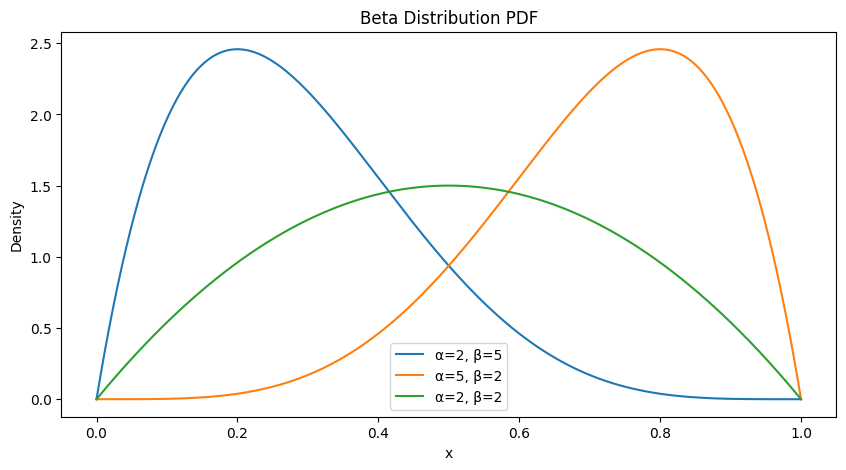

In [ ]:
plt.figure(figsize=(10,5))
for a,b in params_beta:
    plt.plot(x, beta.pdf(x,a,b), label=f'α={a}, β={b}')
plt.title("Beta Distribution PDF")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

When both shape parameters are large and equal, the Beta distribution becomes approximately symmetric and bell-shaped. As shown in the Beta(50,50) plot, the distribution is sharply concentrated around its mean 0.5 and closely resembles a Gaussian distribution. This illustrates the asymptotic connection between the Beta and Normal models.

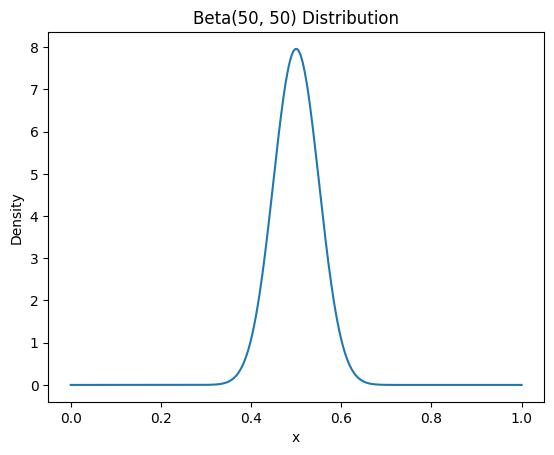

In [ ]:
plt.plot(x, beta.pdf(x, 50, 50))
plt.title("Beta(50, 50) Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [ ]:
# -----------------------------
# Gamma PDF for different k, theta
y = np.linspace(0, 20, 500)
params_gamma = [(2,2), (5,1), (2,5)]

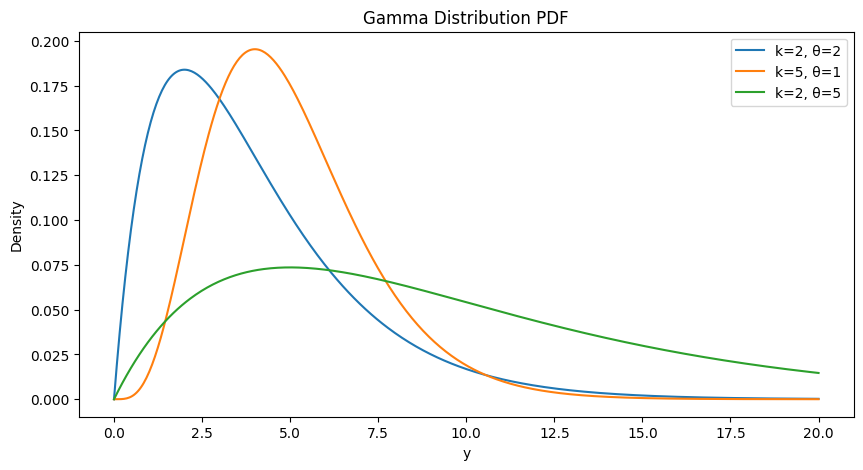

In [ ]:
plt.figure(figsize=(10,5))
for k, theta in params_gamma:
    plt.plot(y, gamma.pdf(y, a=k, scale=theta), label=f'k={k}, θ={theta}')
plt.title("Gamma Distribution PDF")
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# Parameters
k, theta = 50, 1
y = np.linspace(0, 100, 1000)
gamma_pdf = gamma.pdf(y, a=k, scale=theta)    # Corresponding Gaussian parameters
mu = k * theta
sigma = np.sqrt(k) * theta
normal_pdf = norm.pdf(y, mu, sigma)

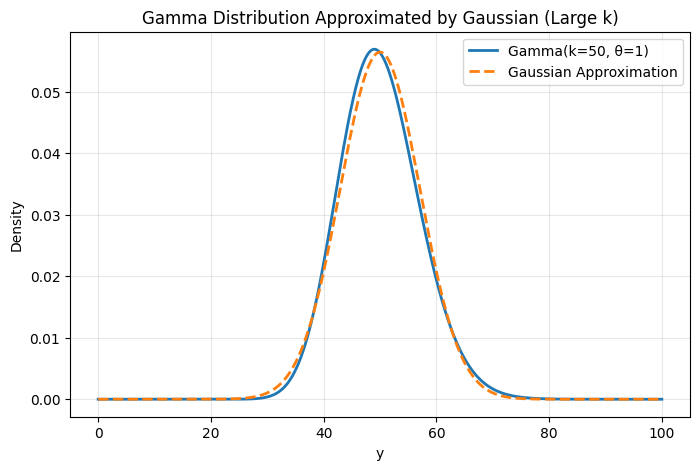

In [ ]:
# Plot
plt.figure(figsize=(8,5))
plt.plot(y, gamma_pdf, label=f'Gamma(k={k}, θ={theta})', linewidth=2)
plt.plot(y, normal_pdf, '--', label='Gaussian Approximation', linewidth=2)
plt.title("Gamma Distribution Approximated by Gaussian (Large k)")
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Connection to the Gaussian Distribution

Both the Beta and Gamma distributions are related to the Gaussian distribution
through asymptotic behavior and the Central Limit Theorem.

For the Beta distribution, although it is bounded on the interval [0,1],
the average of many independent Beta-distributed random variables converges
in distribution to a Normal distribution as the sample size increases,
according to the Central Limit Theorem.

For the Gamma distribution, when the shape parameter k becomes large,
the distribution becomes increasingly symmetric and approaches a Normal
distribution with mean kθ and variance kθ². In addition, the Gamma distribution
can be interpreted as the sum of k independent Exponential random variables
(with scale θ), and by the Central Limit Theorem, this sum converges to a
Gaussian distribution for large k.

These results show that, under suitable conditions, both distributions
exhibit Gaussian behavior.

# Part 2: Simulation Study
We generate **1000 random samples** from each distribution and compare the **empirical mean and variance** to the theoretical values.  

Histograms overlay the theoretical PDF to visually confirm the match.


In [ ]:
# Beta simulation
alpha, beta_param = 2, 5
sample_beta = beta.rvs(alpha, beta_param, size=1000)
x = np.linspace(0, 1, 300)

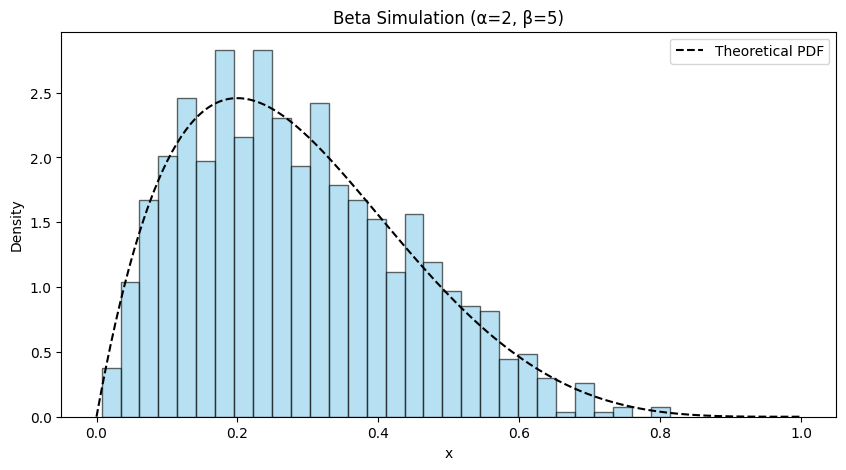

Beta Sample Mean: 0.29, Theoretical Mean: 0.29
Beta Sample Variance: 0.0241, Theoretical Var: 0.0255


In [ ]:
plt.figure(figsize=(10,5))
plt.hist(sample_beta, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x, beta.pdf(x, alpha, beta_param), 'k--', label='Theoretical PDF')
plt.title(f'Beta Simulation (α={alpha}, β={beta_param})')
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()
print(f"Beta Sample Mean: {np.mean(sample_beta):.2f}, Theoretical Mean: {alpha/(alpha+beta_param):.2f}")
print(f"Beta Sample Variance: {np.var(sample_beta):.4f}, Theoretical Var: {alpha*beta_param/((alpha+beta_param)**2*(alpha+beta_param+1)):.4f}")

In [ ]:
# Gamma simulation
k, theta = 2, 2
sample_gamma = gamma.rvs(a=k, scale=theta, size=1000)
y = np.linspace(0, np.max(sample_gamma), 300)

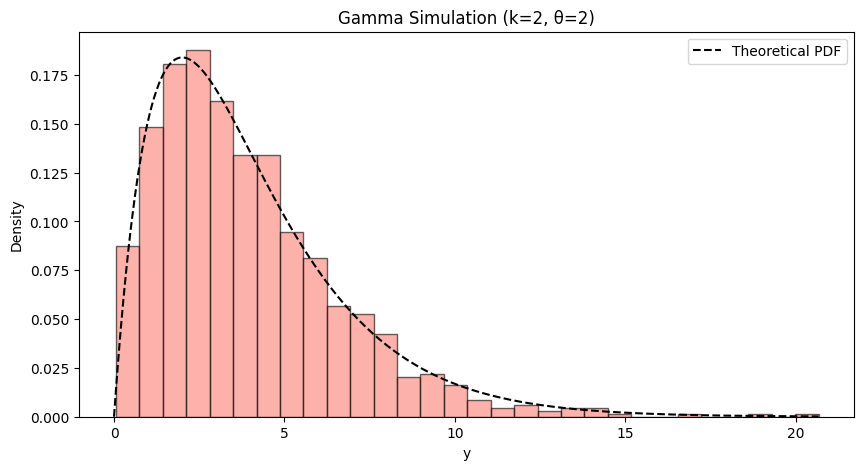

Gamma Sample Mean: 3.92, Theoretical Mean: 4.00
Gamma Sample Variance: 7.33, Theoretical Var: 8.00


In [ ]:
plt.figure(figsize=(10,5))
plt.hist(sample_gamma, bins=30, density=True, alpha=0.6, color='salmon', edgecolor='black')
plt.plot(y, gamma.pdf(y, a=k, scale=theta), 'k--', label='Theoretical PDF')
plt.title(f'Gamma Simulation (k={k}, θ={theta})')
plt.xlabel("y")
plt.ylabel("Density")
plt.legend()
plt.show()
print(f"Gamma Sample Mean: {np.mean(sample_gamma):.2f}, Theoretical Mean: {k*theta:.2f}")
print(f"Gamma Sample Variance: {np.var(sample_gamma):.2f}, Theoretical Var: {k*theta**2:.2f}")

The simulated samples closely match the theoretical distributions.
In both cases, the histograms align well with the corresponding
probability density functions. The empirical mean and variance are
very close to their theoretical values, with small discrepancies
due to random sampling. These results are consistent with the
theoretical properties of the Beta and Gamma distributions and
illustrate the Law of Large Numbers.


 # Part 3: APPLICATION SCENARIO
We consider an online company that monitors user behavior after displaying a
product advertisement. Two quantities of interest are analyzed:

1. The conversion rate, defined as the proportion of users who click on the ad.
2. The time until purchase, defined as the waiting time (in hours) between the
   first click and the final purchase.

The conversion rate is a proportion constrained between 0 and 1, which makes
the Beta distribution a natural modeling choice. The time until purchase is a
positive continuous variable that typically exhibits right skewness, motivating
the use of the Gamma distribution.


For the conversion rate, we assume a Beta distribution with parameters
α = 2 and β = 5. These parameters reflect a situation in which successful
conversions are relatively rare, leading to a right-skewed distribution.

In [ ]:
# Beta: conversion rate
alpha, beta_param = 2, 5
conversion_rate = beta.rvs(alpha, beta_param, size=1000)

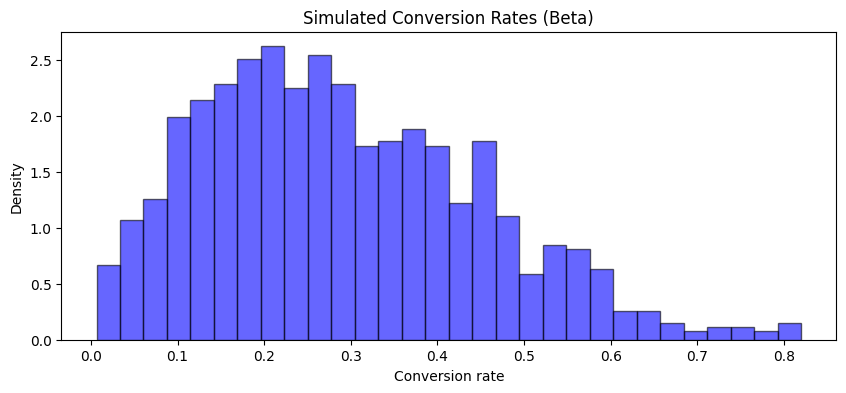

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(conversion_rate, bins=30, density=True, alpha=0.6, color='blue', edgecolor='black')
plt.title("Simulated Conversion Rates (Beta)")
plt.xlabel("Conversion rate")
plt.ylabel("Density")
plt.show()

In [ ]:
print(f"Mean conversion rate: {np.mean(conversion_rate):.3f}")
print(f"Variance conversion rate: {np.var(conversion_rate):.4f}")

Mean conversion rate: 0.289
Variance conversion rate: 0.0252


For the time until purchase, we assume a Gamma distribution with shape
k = 2 and scale θ = 3. The shape parameter models the number of stages
leading to a purchase, while the scale parameter controls the average
duration of each stage.


In [ ]:
# Gamma: time until purchase in hours
k, theta = 2, 3
time_to_purchase = gamma.rvs(a=k, scale=theta, size=1000)

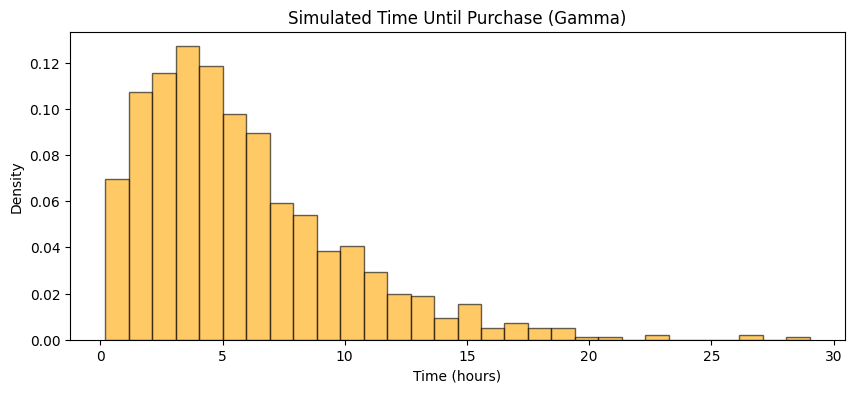

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(time_to_purchase, bins=30, density=True, alpha=0.6, color='orange', edgecolor='black')
plt.title("Simulated Time Until Purchase (Gamma)")
plt.xlabel("Time (hours)")
plt.ylabel("Density")
plt.show()

In [ ]:
# statistics summary
print(f"Mean time until purchase: {np.mean(time_to_purchase):.2f} hours")
print(f"Variance time until purchase: {np.var(time_to_purchase):.2f} hours²")

Mean time until purchase: 5.97 hours
Variance time until purchase: 17.02 hours²


The simulated datasets are consistent with the assumed probabilistic models.
The conversion rate distribution is right-skewed, indicating that most users do
not convert, while a small fraction does. The time-to-purchase distribution
shows right skewness, reflecting that most purchases occur shortly after the
first interaction, with fewer users taking longer times. These results confirm
that the Beta and Gamma distributions are appropriate for modeling proportions
and waiting times, respectively.
